# Figures — learned FBS for TGV$^2$ tomography on real Mayo Clinic CT (512x512)

Run this notebook **after `main.py` has finished training** and saved
`kkt_tomo_512_gamma_1.8_alpha_04.pt` in the repo root. It builds one held-out
Mayo test slice (patient L014) and produces five figures, each saved as a
PDF under `plots/`:

1. **Convergence, log-log** — zero-deviation / learned / random / PDHG.
2. **Safeguard ablation, log-log** — the same learned model run with vs.
   without the safeguard rescaling.
3. **Reconstruction gallery after 10 iterations** — ground truth, naive
   back-projection, zero-deviation, learned, PDHG.
4. **PSNR vs. iteration** — zero / learned / random / PDHG, first 10
   iterations.
5. **Cross-resolution transfer** — the *old* 128x128-trained checkpoint
   (`kkt_tomo_128_gamma_1.8_alpha_04.pt`), applied without any retraining to
   this 512x512 real Mayo instance, vs. zero-deviation and random.

Nothing here is trained. It only loads checkpoints and runs inference/PDHG,
so it is safe to re-run as often as you like once training is done.


## Setup

In [1]:
import os

if not os.path.exists("Algo_setuptorch.py"):
    raise RuntimeError(
        "Run this notebook from the NN_mayo repository root "
        "(the directory that contains Algo_setuptorch.py)."
    )

import numpy as np
import torch
import matplotlib.pyplot as plt
import odl

from Algo_setuptorch import Params, get_setup, build_algo_functions, make_objective
from data.mayo_dataset import MayoSliceDataset
from algorithm.unrolled_model import UnrolledFBS
from algorithm.run import run_zero, run_learned, run_learned_nosafe, run_random
from utils.pdhg_tomography_tgv import build_pdhg_problem
from utils.PSNR import psnr_history
from utils.plots import apply_paper_style, PAPER, _ensure_plots_dir

apply_paper_style()
plots_dir = _ensure_plots_dir("plots")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


[plots] LaTeX rendering: OFF (mathtext fallback)
Device: cuda


In [2]:
# --- must match the configuration main.py used to train the 512 checkpoint ---
SIZE = 512
N_ANGLES = 180
NOISE_LEVEL = 0.05
GAMMA = 2

TEST_PATIENT = "L014"
TEST_SLICE_IDX = 0            # which slice of the held-out patient to use
MAYO_CACHE_DIR = "./data/mayo_cache_512"

CKPT_512 = "kkt_tomo_512_gamma_2_alpha_04.pt"
CKPT_128 = "kkt_tomo_128_gamma_2_alpha_04.pt"

T_SHORT = 10     # the "after 10 iterations" figures (3 and 4)
T_LONG  = 1000   # long-horizon convergence plots (1, 2, 5)

assert os.path.exists(CKPT_512), (
    f"{CKPT_512} not found yet. Run main.py to completion first, "
    "it saves this checkpoint after training."
)


## Build the test problem (one held-out Mayo slice, 512x512)

In [7]:
params = Params(size=SIZE)
params.gamma0 = GAMMA

SHAPES = [
    (1, 1, SIZE, SIZE),   # u  (image)
    (1, 2, SIZE, SIZE),   # w
    (1, 2, SIZE, SIZE),   # p  (dual of grad u - w)
    (1, 3, SIZE, SIZE),   # q  (dual of E w)
]
N_CH_PRIMAL = sum(s[1] for s in SHAPES[:2])   # = 3

test_ds = MayoSliceDataset([TEST_PATIENT], cache_dir=MAYO_CACHE_DIR)
img = test_ds[TEST_SLICE_IDX].squeeze(0).numpy()


setup = get_setup(
    size=SIZE, n_angles=N_ANGLES, seed=TEST_SLICE_IDX,
    noise_level=NOISE_LEVEL, device=device, phantom_array=img,
)
functions = build_algo_functions(setup, params)
initial_state = setup["initial_state"]   # naive back-projection K^T y
clean = setup["phantom"]                 # ground-truth slice
K=setup["K"]


obj_uw = make_objective(setup, params)

print("Test instance:", TEST_PATIENT, "slice", TEST_SLICE_IDX, "-", SIZE, "x", SIZE)


Test instance: L014 slice 0 - 512 x 512


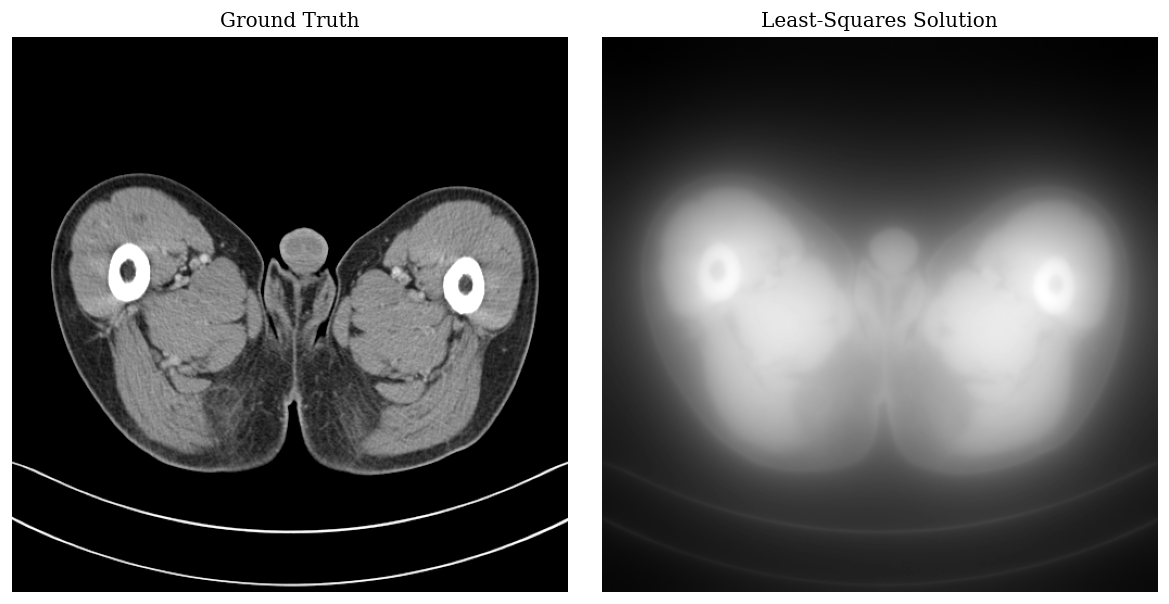

In [ ]:
import matplotlib.pyplot as plt
import torch

u_init = (
    initial_state[0]
)


x_ls = [
    u_init.clone(),  # u : (1, 1, SIZE, SIZE)
    torch.zeros((1, 2, SIZE, SIZE), device=device),  # w
    torch.zeros((1, 2, SIZE, SIZE), device=device),  # p
    torch.zeros((1, 3, SIZE, SIZE), device=device),  # q
]

C_func = functions["C"]  

lr = 1e-2 
n_steps = 100

for step in range(n_steps):
  
    grad_x = C_func(x_ls)

   
    x_ls[0] = x_ls[0] - lr * grad_x[0]


u_ls_img = x_ls[0].detach().squeeze().cpu().numpy()


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))


axes[0].imshow(clean.squeeze().detach().cpu().numpy(), cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("off")

# Solution least squared
axes[1].imshow(u_ls_img, cmap="gray")
axes[1].set_title("Least-Squares Solution")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Load the trained 512 model

In [4]:
model = UnrolledFBS(
    params=params, shapes=SHAPES, n_channels=N_CH_PRIMAL, T=10, alpha=0.99,
).to(device).float()
model.load_state_dict(torch.load(CKPT_512, map_location=device)["model"])
model.eval()
print(f"Loaded {CKPT_512}")


Loaded kkt_tomo_512_gamma_2_alpha_04.pt


## Run zero / learned / random (long horizon)

These three share the same FBS state space, so their KKT residual
$\|(\mathcal{A}+\mathcal{C})(x_n)\|$ is directly comparable. PDHG does not
live in this state space (no dual $p,q$ of the same kind), so it is brought
into the comparison below through the TGV$^2$ objective value instead
(Figure 1).

In [5]:
print("[run_zero] ...")
AxCx_zero, _res_zero, xhist_zero = run_zero(
    initial_state, functions, params, SHAPES, T=T_LONG, device=device)

[run_zero] ...
iter:0
73.99845886230469
iter:1
58.848419189453125
iter:2
46.9566764831543
iter:3
37.52199935913086
iter:4
30.003087997436523
iter:5
23.99932098388672
iter:6
19.201305389404297
iter:7
15.365467071533203
iter:8
12.298402786254883
iter:9
9.84596061706543
iter:10
7.885074615478516
iter:11
6.317418575286865
iter:12
5.064409255981445
iter:13
4.063228130340576
iter:14
3.263680934906006
iter:15
2.625621795654297
iter:16
2.116997241973877
iter:17
1.712158441543579
iter:18
1.3906465768814087
iter:19
1.1360384225845337
iter:20
0.935230016708374
iter:21
0.7776156663894653
iter:22
0.6546810269355774
iter:23
0.5593724846839905
iter:24
0.4860505163669586
iter:25
0.42977437376976013
iter:26
0.3867742717266083
iter:27
0.35379859805107117
iter:28
0.3282601237297058
iter:29
0.3080747127532959
iter:30
0.2918853759765625
iter:31
0.2786578834056854
iter:32
0.2675430476665497
iter:33
0.2578471004962921
iter:34
0.2493247091770172
iter:35
0.24151983857154846
iter:36
0.23449784517288208
iter:37


In [5]:
print("[run_learned] ...")
AxCx_learned, _res_learned, hist_learned = run_learned(
    model, initial_state, clean, functions, T_test=T_LONG, return_all=True)

[run_learned] ...
iter:0
73.99846649169922
iter:1
54.93559646606445
iter:2
42.607051849365234
iter:3
27.84792709350586
iter:4
20.414274215698242
iter:5
10.834169387817383
iter:6
7.971305847167969
iter:7
3.509916067123413
iter:8
2.805184841156006
iter:9
1.2484304904937744
iter:10
1.0407555103302002
iter:11
0.7125083208084106
iter:12
0.6265918016433716
iter:13
0.5617222189903259
iter:14
0.5191425681114197
iter:15
0.4847978949546814
iter:16
0.45372092723846436
iter:17
0.4309820830821991
iter:18
0.40805500745773315
iter:19
0.38957303762435913
iter:20
0.373227596282959
iter:21
0.357148677110672
iter:22
0.3443848192691803
iter:23
0.3307184875011444
iter:24
0.319865882396698
iter:25
0.30834299325942993
iter:26
0.29874444007873535
iter:27
0.28889039158821106
iter:28
0.2802019715309143
iter:29
0.271541565656662
iter:30
0.26371049880981445
iter:31
0.25610026717185974
iter:32
0.2490188032388687
iter:33
0.2421596199274063
iter:34
0.2356792688369751
iter:35
0.2293880730867386
iter:36
0.223442152142

In [ ]:
print("[run_random] ...")
AxCx_random, _res_random, xhist_random = run_random(
    initial_state, functions, params, SHAPES, T=T_LONG, device=device,
    alpha=0.99, seed=0)

[run_random] ...
iter: 0
iter: 1
iter: 2
iter: 3
iter: 4
iter: 5
iter: 6
iter: 7
iter: 8
iter: 9
iter: 10
iter: 11
iter: 12
iter: 13
iter: 14
iter: 15
iter: 16
iter: 17
iter: 18
iter: 19
iter: 20
iter: 21
iter: 22
iter: 23
iter: 24
iter: 25
iter: 26
iter: 27
iter: 28
iter: 29
iter: 30
iter: 31
iter: 32
iter: 33
iter: 34
iter: 35
iter: 36
iter: 37
iter: 38
iter: 39
iter: 40
iter: 41
iter: 42
iter: 43
iter: 44
iter: 45
iter: 46
iter: 47
iter: 48
iter: 49
iter: 50
iter: 51
iter: 52
iter: 53
iter: 54
iter: 55
iter: 56
iter: 57
iter: 58
iter: 59
iter: 60
iter: 61
iter: 62
iter: 63
iter: 64
iter: 65
iter: 66
iter: 67
iter: 68
iter: 69
iter: 70
iter: 71
iter: 72
iter: 73
iter: 74
iter: 75
iter: 76
iter: 77
iter: 78
iter: 79
iter: 80
iter: 81
iter: 82
iter: 83
iter: 84
iter: 85
iter: 86
iter: 87
iter: 88
iter: 89
iter: 90
iter: 91
iter: 92
iter: 93
iter: 94
iter: 95
iter: 96
iter: 97
iter: 98
iter: 99


In [ ]:
obj_zero    = np.array([float(functions["objective"](x)) for x in xhist_zero])
obj_learned = np.array([float(functions["objective"](x)) for x in hist_learned["x"]])
obj_random  = np.array([float(functions["objective"](x)) for x in xhist_random])


### Run PDHG (reference solver, tracked every iteration)

In [ ]:
class PDHGTracker:
    """odl callback: records the objective and PSNR at every PDHG iteration,
    and keeps the reconstructed image at the iterations in `snapshot_iters`
    (used below to grab the iterate at n=10 for the reconstruction gallery)."""

    def __init__(self, obj_fn, clean_img, device, snapshot_iters=()):
        self.obj_fn = obj_fn
        self.clean = clean_img
        self.device = device
        self.snapshot_iters = set(snapshot_iters)
        self.obj_hist = []
        self.psnr_hist = []
        self.snapshots = {}
        self._n = 0

    def __call__(self, x):
        self._n += 1
        u = torch.tensor(np.asarray(x[0]), dtype=torch.float32,
                          device=self.device).unsqueeze(0).unsqueeze(0)
        w = torch.tensor(np.asarray(x[1]), dtype=torch.float32,
                          device=self.device).unsqueeze(0)
        self.obj_hist.append(float(self.obj_fn(u, w)))
        self.psnr_hist.append(psnr_history([u], self.clean)[0])
        if self._n in self.snapshot_iters:
            self.snapshots[self._n] = u.clone()


op, f, g, domain = build_pdhg_problem(setup, params)
op_norm = 1.1 * odl.power_method_opnorm(op, maxiter=50)
tau = sigma = 1.0 / op_norm

print("[PDHG] ...")
pdhg_tracker = PDHGTracker(obj_uw, clean, device, snapshot_iters={T_LONG})
x_pdhg = op.domain.zero()
odl.solvers.pdhg(x_pdhg, f, g, op, niter=T_LONG, tau=tau, sigma=sigma,
                  callback=pdhg_tracker)

obj_pdhg = np.array(pdhg_tracker.obj_hist)
psnr_pdhg_full = pdhg_tracker.psnr_hist
pdhg_10 = pdhg_tracker.snapshots[T_LONG-1]


[PDHG] ...


KeyError: 999

## Figure 1 — convergence: zero vs. learned vs. random vs. PDHG

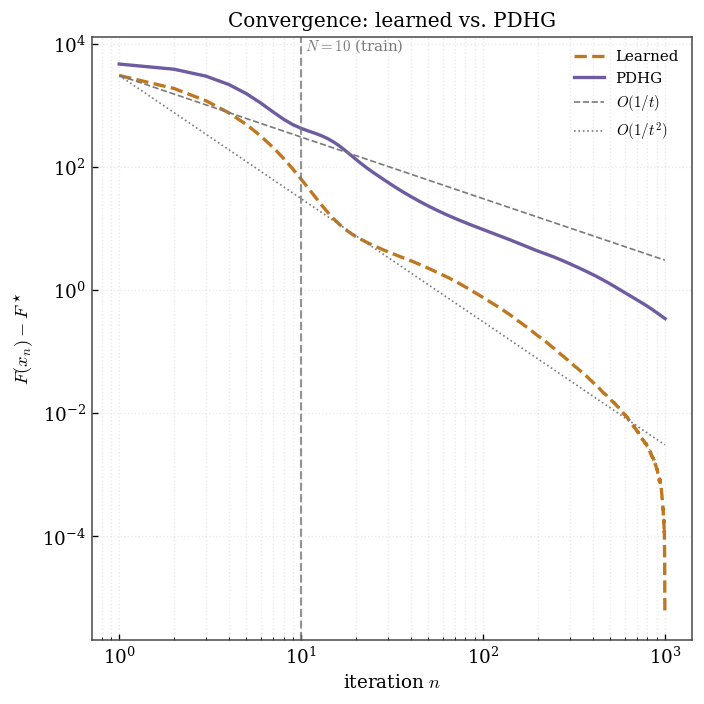

In [ ]:
EPS_PLOT = 1e-6  # below this threshold, the "gap" is only numerical noise

def trim_at_floor(obj_curve, f_star, eps=EPS_PLOT):
    raw_gap = obj_curve - f_star
    below = np.where(raw_gap < eps)[0]
    n = below[0] if len(below) else len(raw_gap)
    return max(n, 1)


f_star = min(
    
    obj_zero.min(),
    
    obj_pdhg.min()
)


n_learned = trim_at_floor(obj_zero, f_star)

n_pdhg = trim_at_floor(obj_pdhg, f_star)




gap_learned = np.clip(
    obj_zero[:n_learned] - f_star,
    1e-8, None
)



gap_pdhg = np.clip(
    obj_pdhg[:n_pdhg] - f_star,
     1e-8, None
)


# ============================================================
# Plot: zero vs. learned vs. random
# ============================================================

plt.figure(figsize=(6, 6))



plt.loglog(
    range(1, len(gap_learned) + 1),
    gap_learned,
    label="Learned",
    color=PAPER["orange"],
    linestyle="--"
)


plt.loglog(
    range(1, len(gap_pdhg) + 1),
     gap_pdhg,
     label="PDHG",
    color=PAPER["purple"],
    linestyle="-"
)


# ============================================================
# O(1/n) and O(1/n^2) reference curves
# ============================================================

n_max = len(gap_learned)


n_ref = np.arange(1, n_max + 1)

# Anchor the reference curves at the first point of the learned curve
g0 = float(gap_learned[0])

plt.loglog(
    n_ref,
    g0 / n_ref,
    color=PAPER["gray"],
    lw=1.0,
    ls="--",
    label=r"$O(1/t)$"
)

plt.loglog(
    n_ref,
    g0 / n_ref**2,
    color=PAPER["gray"],
    lw=1.0,
    ls=":",
    label=r"$O(1/t^2)$"
)


# ============================================================
# Vertical line at N=10 (training)
# ============================================================

plt.axvline(
    10,
    color=PAPER["gray"],
    lw=1.3,
    ls="--",
    alpha=0.8
)

plt.text(
    10,
    plt.ylim()[1],
    r" $N=10$ (train)",
    color=PAPER["gray"],
    va="top",
    ha="left",
    fontsize=9
)


# ============================================================
# Formatting
# ============================================================

plt.xlabel("iteration $n$")
plt.ylabel(r"$F(x_n)-F^\star$")
plt.title("Convergence: learned vs. PDHG")

plt.legend(fontsize=9)
plt.grid(
    True,
    which="both",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        plots_dir,
        "convergence_learned_pdhg.pdf"
    )
)

plt.show()

Same trained (safeguarded) model, run twice: once through `run_learned`
(deviations rescaled by the safeguard, Theorem-backed convergence), once
through `run_learned_nosafe` (raw deviations applied directly, no budget
rescaling). This isolates what the safeguard buys, expect the unsafeguarded
curve to do fine early and then blow up.

## Figure 3 — reconstruction gallery after 10 iterations

In [ ]:
zero_10    = xhist_zero[T_LONG - 1][0]
#learned_10 = hist_learned["x"][T_SHORT - 1][0]
pdhg_10_img = pdhg_10

def _psnr1(img):
    return psnr_history([img], clean)[0]

panels = [
    ("Ground truth",    clean,         None),
    ("Back-projection", initial_state, _psnr1(initial_state)),
    ("Learned",  zero_10,       _psnr1(zero_10)),

    ("PDHG",            pdhg_10_img,   _psnr1(pdhg_10_img)),
]

fig, axes = plt.subplots(1, len(panels), figsize=(3.0 * len(panels), 4))
for ax, (title, im, psnr) in zip(axes, panels):
    ax.imshow(im.squeeze().detach().cpu().numpy(), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "reconstruction_gallery_10iters.pdf"))
plt.show()


KeyError: 999